Áreas encontradas: ['CA3b', 'CA3c', 'DGD', 'DGV']

=== Geral ===
67/349 combinações (arquivo x área) com harmônica de theta caindo em Gamma Lento (19.2%)

=== Por área ===


,n_alerta,n_total,pct_alerta
area,,,
CA3b,24,77,31.2
CA3c,16,89,18.0
DGD,8,92,8.7
DGV,19,91,20.9



=== Por condição ===


,n_alerta,n_total,pct_alerta
condicao,,,
0.25,19,95,20.0
0.5,12,82,14.6
0.75,29,92,31.5
NOR,7,80,8.8



=== Área x condição (percentual de alerta) ===


condicao,0.25,0.5,0.75,NOR
area,,,,
CA3b,45.0,15.8,47.8,6.7
CA3c,16.0,14.3,31.8,9.5
DGD,4.0,14.3,12.5,4.5
DGV,20.0,14.3,34.8,13.6


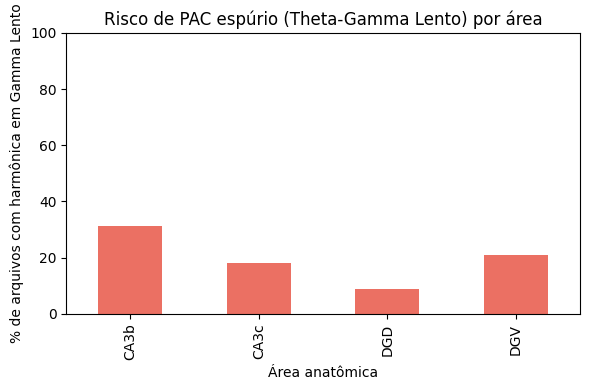


[Aviso] A coluna "<area>_theta_peak_hz" não existe em features_all — o pipeline hoje só salva o FLAG de alerta, não o valor do pico em si. Se quiser essa estatística (tipo "pico variou de 6,8 a 7,8 Hz"), adicione esta linha no loop "6. FEATURES + PLOTS POR ÁREA" do pipeline principal, ao lado de onde "centroide_hz" é calculado:

    row_feat[f"{prefix}_theta_peak_hz"] = theta_peaks[area]



In [2]:
# ═══════════════════════════════════════════════════════════════
# Pós-EDA — Estatísticas de harmônicas de Theta vs Gamma Lento
# Usa a tabela consolidada features_all (uma linha por segundo,
# colunas "<area>_pac_sl_alerta" = True/False, uma por área).
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path
OUTPUT_DIR  = Path('EDA_outputs')
arquivo = OUTPUT_DIR / 'features_all.csv'
df = pd.read_csv(arquivo, low_memory=False)

# Detecta automaticamente as áreas presentes a partir das colunas
# "<area>_pac_sl_alerta"
areas_presentes = sorted({
    col.replace('_pac_sl_alerta', '')
    for col in df.columns if col.endswith('_pac_sl_alerta')
})
print(f'Áreas encontradas: {areas_presentes}')

# O flag de alerta é constante dentro de um mesmo (stem, área) —
# colapsa para 1 linha por (stem, área) antes de agregar
linhas = []
for area in areas_presentes:
    col_alerta = f'{area}_pac_sl_alerta'
    sub = (
        df[['stem', 'rato', 'condicao', col_alerta]]
        .dropna(subset=[col_alerta])
        .drop_duplicates(subset=['stem'])
        .rename(columns={col_alerta: 'alerta'})
    )
    sub['area'] = area
    linhas.append(sub)

df_alerta = pd.concat(linhas, ignore_index=True)
df_alerta['alerta'] = df_alerta['alerta'].astype(bool)

# ── 1) Percentual geral de arquivos x área com harmônica em Gamma Lento ──
pct_geral = df_alerta['alerta'].mean() * 100
n_total = len(df_alerta)
n_alerta = int(df_alerta['alerta'].sum())
print(f'\n=== Geral ===')
print(f'{n_alerta}/{n_total} combinações (arquivo x área) com harmônica '
      f'de theta caindo em Gamma Lento ({pct_geral:.1f}%)')

# ── 2) Por área anatômica ──
print(f'\n=== Por área ===')
tabela_area = (
    df_alerta.groupby('area')['alerta']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'n_alerta', 'count': 'n_total', 'mean': 'pct_alerta'})
)
tabela_area['pct_alerta'] = (tabela_area['pct_alerta'] * 100).round(1)
display(tabela_area)

# ── 3) Por condição de similaridade ──
print(f'\n=== Por condição ===')
tabela_condicao = (
    df_alerta.groupby('condicao')['alerta']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'n_alerta', 'count': 'n_total', 'mean': 'pct_alerta'})
)
tabela_condicao['pct_alerta'] = (tabela_condicao['pct_alerta'] * 100).round(1)
display(tabela_condicao)

# ── 4) Cruzamento área x condição (% de alerta) ──
print(f'\n=== Área x condição (percentual de alerta) ===')
pivot = (
    df_alerta.pivot_table(index='area', columns='condicao',
                           values='alerta', aggfunc='mean') * 100
).round(1)
display(pivot)

# ── 5) Gráfico de barras: % de alerta por área ──
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
tabela_area['pct_alerta'].plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_ylabel('% de arquivos com harmônica em Gamma Lento')
ax.set_xlabel('Área anatômica')
ax.set_title('Risco de PAC espúrio (Theta-Gamma Lento) por área')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pct_alerta_harmonicas_por_area.png', dpi=150)
plt.show()

# ── 6) (Opcional) Frequência do pico theta, se você salvar essa coluna ──
cols_theta_peak = [c for c in df.columns if c.endswith('_theta_peak_hz')]
if cols_theta_peak:
    linhas_peak = []
    for col in cols_theta_peak:
        area = col.replace('_theta_peak_hz', '')
        sub = df[['stem', 'rato', 'condicao', col]].dropna().drop_duplicates(subset=['stem'])
        sub = sub.rename(columns={col: 'theta_peak_hz'})
        sub['area'] = area
        linhas_peak.append(sub)
    df_peak = pd.concat(linhas_peak, ignore_index=True)
    print('\n=== Pico theta por área (Hz) ===')
    display(df_peak.groupby('area')['theta_peak_hz']
            .describe()[['mean', 'std', 'min', 'max']].round(2))
else:
    print('\n[Aviso] A coluna "<area>_theta_peak_hz" não existe em features_all — '
          'o pipeline hoje só salva o FLAG de alerta, não o valor do pico em si. '
          'Se quiser essa estatística (tipo "pico variou de 6,8 a 7,8 Hz"), '
          'adicione esta linha no loop "6. FEATURES + PLOTS POR ÁREA" do pipeline '
          'principal, ao lado de onde "centroide_hz" é calculado:\n\n'
          '    row_feat[f"{prefix}_theta_peak_hz"] = theta_peaks[area]\n')